In [12]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from data_preprocessing import preprocess

ModuleNotFoundError: No module named 'data_preprocessing'

In [3]:
filepath = "/Users/saumyamishra/Desktop/Ashoka/sem 5/Introduction to Machine Learning/Saumya_Mishra_A1/decision_tree_task/data/train_data.csv"
dataset = pd.read_csv(filepath, usecols=lambda x: x not in ["isFlaggedFraud"])
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,686,CASH_OUT,1467968.73,C1032013375,1467968.73,0.00,C293921513,0.00,1467968.73,1
1,210,CASH_OUT,113615.25,C1933223662,7905.00,0.00,C657984082,597940.50,711555.75,0
2,308,CASH_IN,57180.32,C483203297,2249932.73,2307113.05,C1835281457,206526.46,149346.14,0
3,34,CASH_IN,222389.38,C703351260,6846615.66,7069005.04,C163255774,449960.13,227570.75,0
4,276,CASH_OUT,41845.14,C1597072697,0.00,0.00,C421084235,3341767.77,3383612.91,0


In [11]:
#statistics about dataset
dataset.info()

#duplicates
dataset.duplicated().sum()

#missing data
dataset.isnull().sum()

dataset['step'].value_counts()

dataset['isFraud'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5090096 entries, 0 to 5090095
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 388.3+ MB


isFraud
0    5083503
1       6593
Name: count, dtype: int64

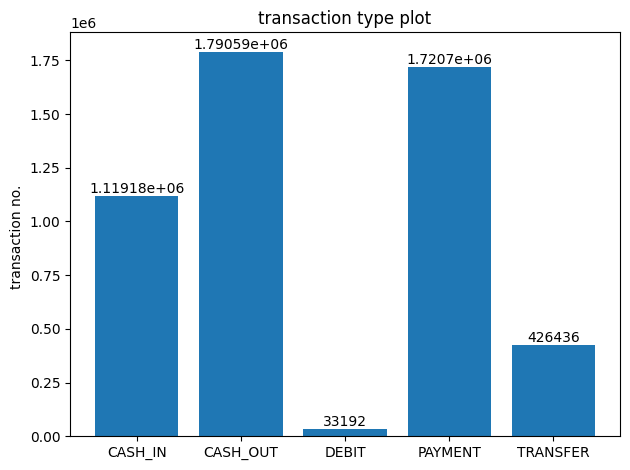

In [12]:
types, counts = np.unique(dataset['type'], return_counts=True)

fig, ax = plt.subplots()
bars = ax.bar(types, counts)

ax.bar_label(bars)

ax.set_title('transaction type plot')
ax.set_ylabel('transaction no. ')

ax.set_xticks(range(len(types)))
ax.set_xticklabels(types)

plt.tight_layout()

plt.show()

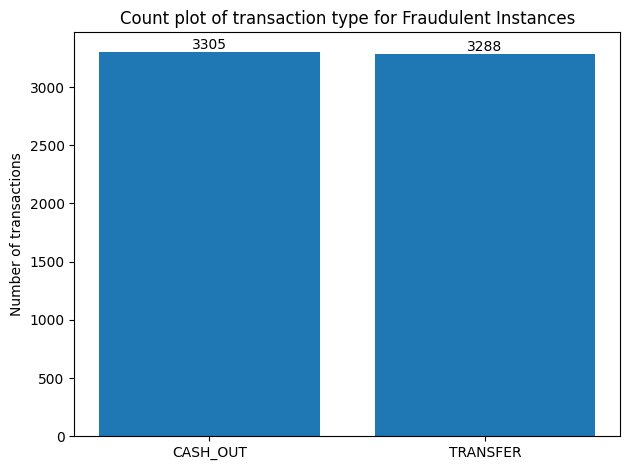

In [13]:
fraud_data = dataset[dataset['isFraud'] == 1]

types, counts = np.unique(fraud_data['type'], return_counts=True)
fig, ax = plt.subplots()
bars = ax.bar(types, counts)
ax.bar_label(bars)
ax.set_title('Count plot of transaction type for Fraudulent Instances')
ax.set_ylabel('Number of transactions')
ax.set_xticks(range(len(types)))
ax.set_xticklabels(types)
plt.tight_layout()
plt.show()

dataset['fraud_type'] = dataset['type'].apply(lambda x: 1 if x in ['CASH_OUT', 'TRANSFER'] else 0)

since fraud only happens in cash_out or transfer, we will make a column that marks one if it is either of these, and 0 otherwise, and will drop type.

In [4]:
dataset['fraud_type'] = dataset['type'].apply(lambda x: 1 if x in ['CASH_OUT', 'TRANSFER'] else 0)

In [15]:
fraud_data.sample(30)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
372173,90,CASH_OUT,113309.55,C1936469791,113309.55,0.00,C471979620,0.00,113309.55,1
3514203,340,TRANSFER,26478.48,C1021627549,26478.48,0.00,C513494131,0.00,0.00,1
540972,156,CASH_OUT,157705.36,C599834938,157705.36,0.00,C522259302,0.00,157705.36,1
2105417,137,TRANSFER,417217.89,C2118315952,417217.89,0.00,C1765086127,0.00,0.00,1
3935834,40,TRANSFER,2757431.53,C1340596396,2757431.53,0.00,C487414422,0.00,0.00,1
1369717,483,CASH_OUT,22990.73,C919319560,22990.73,0.00,C856187523,3279840.64,3302831.37,1
776533,406,TRANSFER,20842.92,C2099780546,20842.92,0.00,C1566929124,0.00,0.00,1
4226661,352,TRANSFER,614145.31,C1021093618,614145.31,0.00,C1029613730,0.00,0.00,1
2633360,459,TRANSFER,46130.88,C1045907901,46130.88,0.00,C1384446029,0.00,0.00,1
1735244,251,TRANSFER,8276235.50,C1112360108,8276235.50,0.00,C1241281307,0.00,0.00,1


In [5]:
dataset['full_withdraw'] = dataset.apply(lambda row: 1 if row['amount'] == row['oldbalanceOrg'] else 0, axis=1)


In [6]:
rows1 = len(dataset[(dataset['full_withdraw'] == 0) & (dataset['isFraud'] == 1)])
print('Number of frauds that are not full withdrawals:')
print(rows1)

rows2 = len(dataset[(dataset['full_withdraw'] == 1) & (dataset['isFraud'] == 0)])
print('Full withdrawals that are not frauds:')
print(rows2)

Number of frauds that are not full withdrawals:
127
Full withdrawals that are not frauds:
0


clearly, amount == oldBalanceOrg is a necessary (but not sufficient) criterion to say that a transaction is fradulent. so, we will make a column marking a 1 if they are equal, and 0 otherwise.

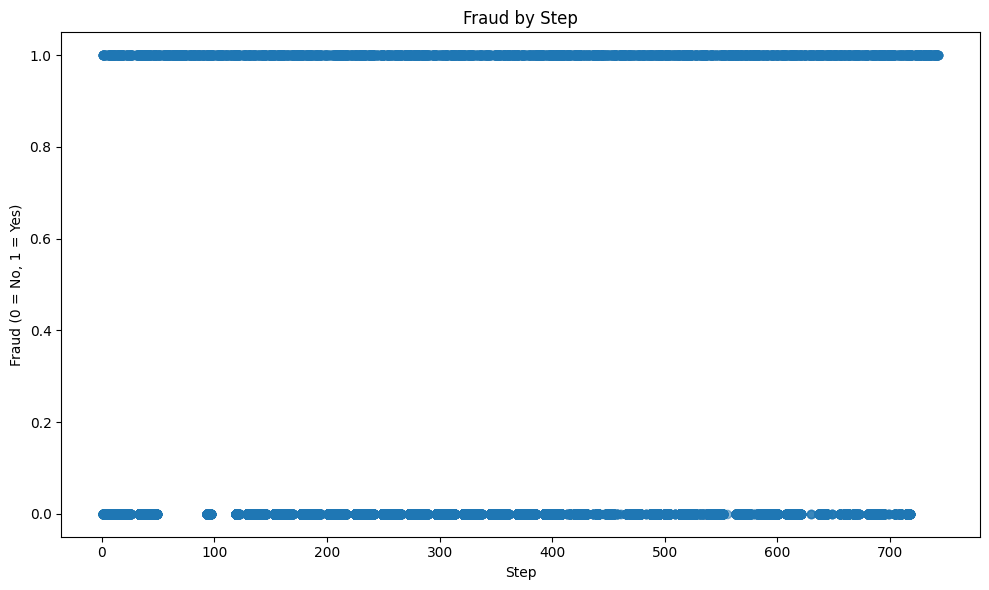

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(dataset['step'], dataset['isFraud'], alpha=0.5)

plt.title('Fraud by Step')
plt.xlabel('Step')
plt.ylabel('Fraud (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()


there appears to be a gap between 55 and 110 where there is only fraud taking place. we will add another column for points that are in this range, as follows:

In [8]:
dataset['suspcisious_time_frame'] = dataset['step'].apply(lambda x: 10 if 55 <= x <= 110 else 5)
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
0,686,CASH_OUT,1467968.73,C1032013375,1467968.73,0.00,C293921513,0.00,1467968.73,1,1,1,5
1,210,CASH_OUT,113615.25,C1933223662,7905.00,0.00,C657984082,597940.50,711555.75,0,1,0,5
2,308,CASH_IN,57180.32,C483203297,2249932.73,2307113.05,C1835281457,206526.46,149346.14,0,0,0,5
3,34,CASH_IN,222389.38,C703351260,6846615.66,7069005.04,C163255774,449960.13,227570.75,0,0,0,5
4,276,CASH_OUT,41845.14,C1597072697,0.00,0.00,C421084235,3341767.77,3383612.91,0,1,0,5


In [9]:
dataset.drop(columns=['type'], inplace=True)


In [10]:
dataset.drop(columns=['nameOrig', 'nameDest'], inplace=True)

In [11]:
dataset.corr()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
step,1.000000,0.067463,0.001807,-0.013472,0.022401,0.025367,0.149645,0.021637,0.147912,-0.092560
amount,0.067463,1.000000,0.120936,0.004900,0.236190,0.393066,0.310179,0.212252,0.269175,0.044344
oldbalanceOrg,0.001807,0.120936,1.000000,0.983569,0.065765,0.052222,0.052435,-0.217522,0.030810,0.008586
newbalanceOrig,-0.013472,0.004900,0.983569,1.000000,0.071296,0.043979,-0.040010,-0.251922,-0.051283,-0.005942
oldbalanceDest,0.022401,0.236190,0.065765,0.071296,1.000000,0.975483,-0.027684,0.142314,-0.026787,-0.008393
newbalanceDest,0.025367,0.393066,0.052222,0.043979,0.975483,1.000000,0.004626,0.186887,0.005793,-0.004015
isFraud,0.149645,0.310179,0.052435,-0.040010,-0.027684,0.004626,1.000000,0.199995,0.987976,0.165137
fraud_type,0.021637,0.212252,-0.217522,-0.251922,0.142314,0.186887,0.199995,1.000000,0.197590,0.017744
full_withdraw,0.147912,0.269175,0.030810,-0.051283,-0.026787,0.005793,0.987976,0.197590,1.000000,0.165812
suspcisious_time_frame,-0.092560,0.044344,0.008586,-0.005942,-0.008393,-0.004015,0.165137,0.017744,0.165812,1.000000


In [22]:
dataset.drop(columns=['newbalanceDest', 'oldbalanceDest', 'step'], inplace=True)

In [25]:
dataset.drop(columns=['newbalanceOrig', 'oldbalanceOrg', 'amount'], inplace=True)
dataset.head()

,isFraud,fraud_type,full_withdraw,suspcisious_time_frame
0,0,0,0,5
1,0,0,0,5
2,0,0,0,5
3,0,1,0,5
4,0,1,0,5


This is what the final dataframe looks like.